## DATASET: Employment - Owen Lecky


#### One of the metrics being used to determine what is the best pittsburgh neighborhood to live in was empoyment for people over the age of 16. This metric is important to check because you dont want to move to a town where its hard to find work. You also want your friends to be sucessful so they can promote your own sucess. Its harder to find sucessful people in a town where nobody works.


In [45]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("d53bfc16-9518-4c5b-b102-847654dabe21.csv")
data = data.rename(columns={"Estimate; Total:": "Estimated total population:", "Estimate; Not in labor force":"Estimated unemployed:"})
dataNoExcess = data.drop(columns=["Margin of Error; Total:","Id","Margin of Error; In labor force:","Margin of Error; In labor force: - Civilian labor force:","Margin of Error; In labor force: - Civilian labor force: - Empl","Margin of Error; In labor force: - Civilian labor force: - Unem","Margin of Error; In labor force: - Armed Forces","Margin of Error; Not in labor force"])
dataNoExcess["Percent not working:"] = (dataNoExcess["Estimated unemployed:"] / dataNoExcess["Estimated total population:"])*100
dataNoExcess["Percent working:"] = 100-((dataNoExcess["Estimated unemployed:"] / dataNoExcess["Estimated total population:"])*100)

#### Above, I imported the dataset, removed some of the unneeded columns, and renamed some to make it easier visually. I also added my own percentage column to the dataset that looks at the percent of people that work in the town.

### Onto the Lowest percent of employed people:

In [46]:
dataSortedD = dataNoExcess.sort_values(by="Percent not working:", ascending = False)
dataSortedD=dataSortedD.drop(columns=["_id","Estimate; In labor force:","Estimate; In labor force: - Civilian labor force:","Estimate; In labor force: - Civilian labor force: - Employed","Estimate; In labor force: - Civilian labor force: - Unemployed","Estimate; In labor force: - Armed Forces"])
dataSortedD.head()

,Neighborhood,Estimated total population:,Estimated unemployed:,Percent not working:,Percent working:
35,Glen Hazel,577.0,489.0,84.748700,15.251300
10,Bluff,5990.0,4083.0,68.163606,31.836394
49,Marshall-Shadeland,5687.0,3655.0,64.269386,35.730614
56,North Oakland,9510.0,5638.0,59.284963,40.715037
23,Crawford-Roberts,1803.0,1055.0,58.513588,41.486412


#### Using this new organized dataset, we can see that the Glen Hazel is the neighborhood with the lowest percentage of working population, with a shocking 84% of people not being in the labor force.

### Onto the Highest percent of employed people:

In [47]:
dataSortedA = dataNoExcess.sort_values(by="Percent working:",ascending = False)
dataSortedA=dataSortedA.drop(columns=["_id","Estimate; In labor force:","Estimate; In labor force: - Civilian labor force:","Estimate; In labor force: - Civilian labor force: - Employed","Estimate; In labor force: - Civilian labor force: - Unemployed","Estimate; In labor force: - Armed Forces"])
dataSortedA.head(10)

,Neighborhood,Estimated total population:,Estimated unemployed:,Percent not working:,Percent working:
71,South Shore,12.0,0.0,0.000000,100.000000
57,North Shore,179.0,14.0,7.821229,92.178771
80,Strip District,658.0,67.0,10.182371,89.817629
31,Fairywood,1076.0,182.0,16.914498,83.085502
33,Friendship,1674.0,337.0,20.131422,79.868578
26,East Carnegie,471.0,100.0,21.231423,78.768577
65,Polish Hill,1338.0,336.0,25.112108,74.887892
11,Bon Air,718.0,188.0,26.183844,73.816156
47,Lower Lawrenceville,2225.0,583.0,26.202247,73.797753
63,Point Breeze,4538.0,1213.0,26.729837,73.270163


#### Now, its clear to see that the South Shore is the highest percentage of people in the labor force. Because the population is only 12 however, The North Shore or the Strip District can be considered the two neighborhoods with the highest percent of working population.

#### Below is a graph to help visualize the data:

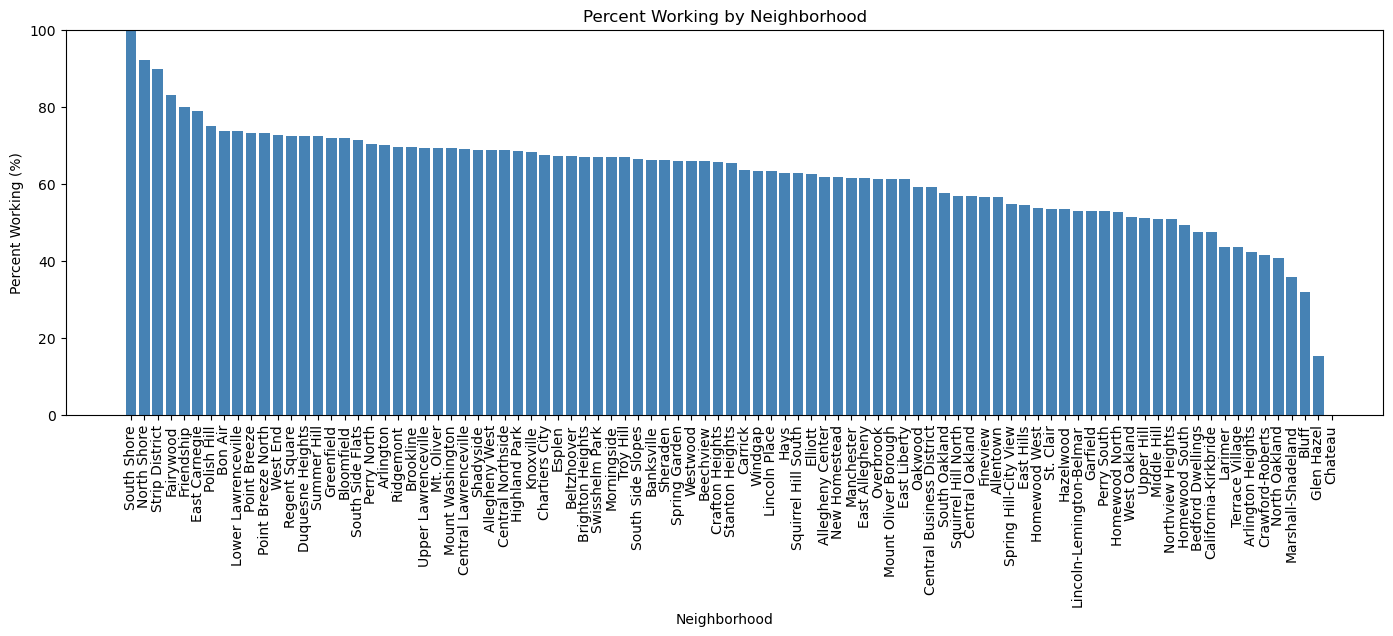

In [48]:
plt.figure(figsize=(17, 5))

plt.bar(dataSortedA["Neighborhood"], dataSortedA["Percent working:"], color='steelblue')

plt.xlabel("Neighborhood")
plt.ylabel("Percent Working (%)")
plt.title("Percent Working by Neighborhood")

plt.ylim(0, 100)
plt.xticks(rotation=90)

plt.show()